# Computer Vision - P2

## Delivery

Up to **1 point out of 10** will be penalized if the following requirements are not fulfilled:

- Implemented code should be commented.

- The questions introduced in the exercises must be answered.

- Comments need to be in **english**.

- The deliverable must be a file named **P2_Student1_Student2.zip** that includes:
    - The notebook P2_Student1_Student2.ipynb completed with the solutions to the exercises and their corresponding comments.
    - All the images used in this notebook.

**Deadline (Campus Virtual): October 22nd, 23:00 h** 

==============================================================================================
## Practicum 2: Filtering and edge detection

==============================================================================================

The main topics are:
1. Image smoothing and convolution (exercises 2.1, 2.2, 2.3 and 2.4)
2. Edge detection (exercises 2.5, 2.6 and 2.7)

In order to complete this practicum, the following concepts need to be understood: linear filters, histograms, convolutions, and edges.

The following chapters of the book "Computer Vision: Algorithms and Applications" by Richard Szeliski provide additional information:
* Chapter 3. Image processing: Point operators & linear filtering.
* Chapter 4. Feature detection and matching: Edges.

In [1]:
# Important packages
import numpy as np # useful for manipulating matrices
from skimage import io, img_as_ubyte, img_as_uint, img_as_float # useful for image loading and saving
from matplotlib import pyplot as plt # useful for plotting images on iPython or Jupyter Notebooks
from skimage.color import rgb2gray, rgba2rgb
from scipy.ndimage import convolve
from skimage.transform import resize, rescale
from skimage.exposure import rescale_intensity, histogram, cumulative_distribution

### 2.1 RGB histogram visualization

a) Read the image `./images_notebook/oryx.png` and visualize the RGB image as well as each of its channels separately (R, G, and B). Print the image shape and data type.

<img src="images_notebook/oryx.jpg">

**Note:** Before applying the histogram, you should pass the image into float.

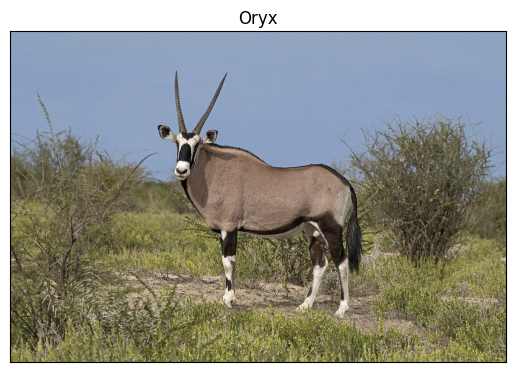

(800, 1200, 3)
uint8
255
0


In [2]:
# Load image
oryx = img_as_ubyte(io.imread("images_notebook/oryx.jpg"))
plt.imshow(oryx)
plt.xticks([]); plt.yticks([]) # Off ticks
plt.title("Oryx")
plt.show()

# Check its dimensions, max and min pixel value and type
print(oryx.shape)
print(oryx.dtype)
print(oryx.max())
print(oryx.min())

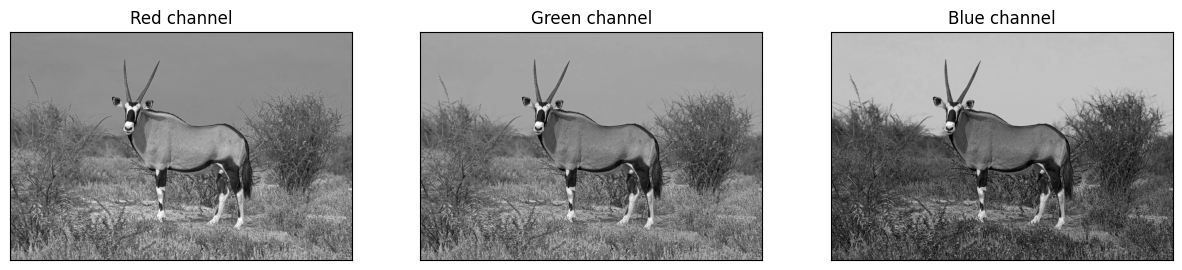

In [3]:
r = oryx[:, :, 0]  # Red
g = oryx[:, :, 1]  # Green
b = oryx[:, :, 2]  # Blue
ig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

ax = axs[0]
ax.imshow(r, cmap="gray") # Alternatively, cmap="Reds"
ax.set_title('Red channel')

ax = axs[1]
ax.imshow(g,cmap="gray") # Alternatively, cmap="Greens"
ax.set_title("Green channel")

ax = axs[2]
ax.imshow(b,cmap="gray") # Alternatively, cmap="Blues"
ax.set_title("Blue channel")

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

b) Make a function `im_hist(im,  nbins=8)` to visualize the histogram of the RGB, and grayscale images. What is the histogram representing for an image? 

The plotted histogram must accomplish these requirements (see image bellow as an example of histogram extraction):

- Obtain the histogram with 16, 32, 64 and 256 bins. What are the bins representing?

- Visualize the histogram of each channel and the gray level image separately and compare them. Comment their differences (between different channels and different number of bins).

**Note:** What type should be the image in order to compute the histogram? Check using different bins for the histogram. 

**Hint** : the `exposure` module within the `skimage` library makes the histogram extraction easy!

**Help:** [matplotlib image tutorial](https://matplotlib.org/users/image_tutorial.html)

<img src='images_notebook/histograms.png'>

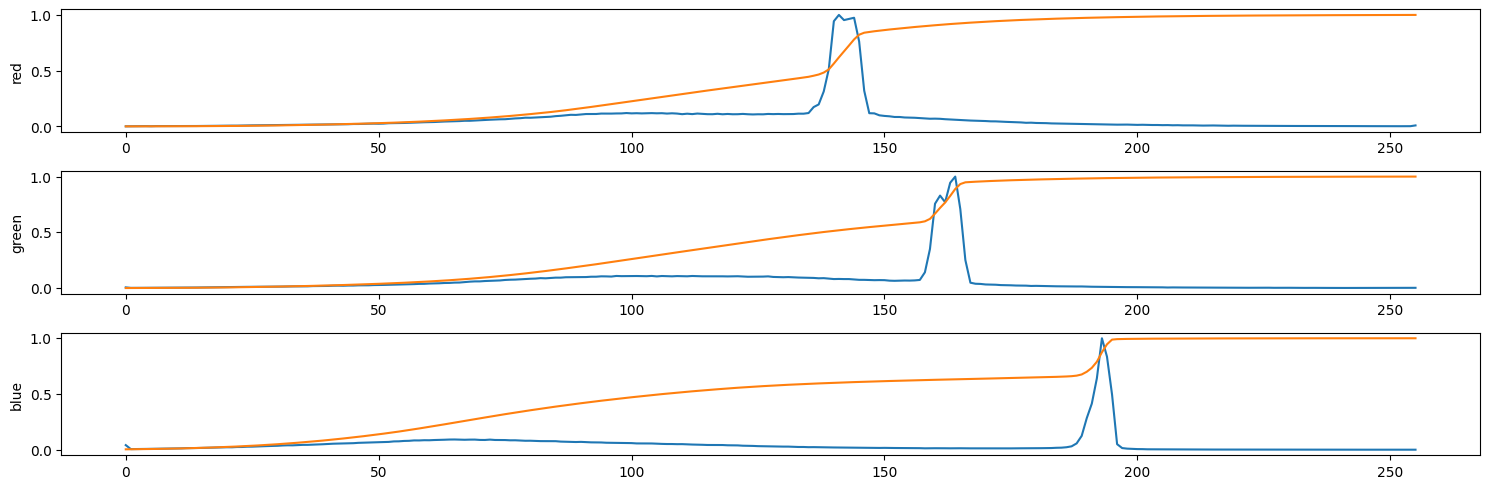

In [4]:
# Cf. https://scikit-image.org/docs/stable/auto_examples/color_exposure/plot_histogram_matching.html
def im_hist(image):
    
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 5))
    for c, c_color in enumerate(('red', 'green', 'blue')):
        img_hist, bins = histogram(image[..., c], source_range='image', normalize=False)
        axes[c].plot(bins, img_hist / img_hist.max())
        img_cdf, bins = cumulative_distribution(image[..., c])
        axes[c].plot(bins, img_cdf)
        axes[c].set_ylabel(c_color)
    
    plt.tight_layout()
    plt.show()

im_hist(oryx)

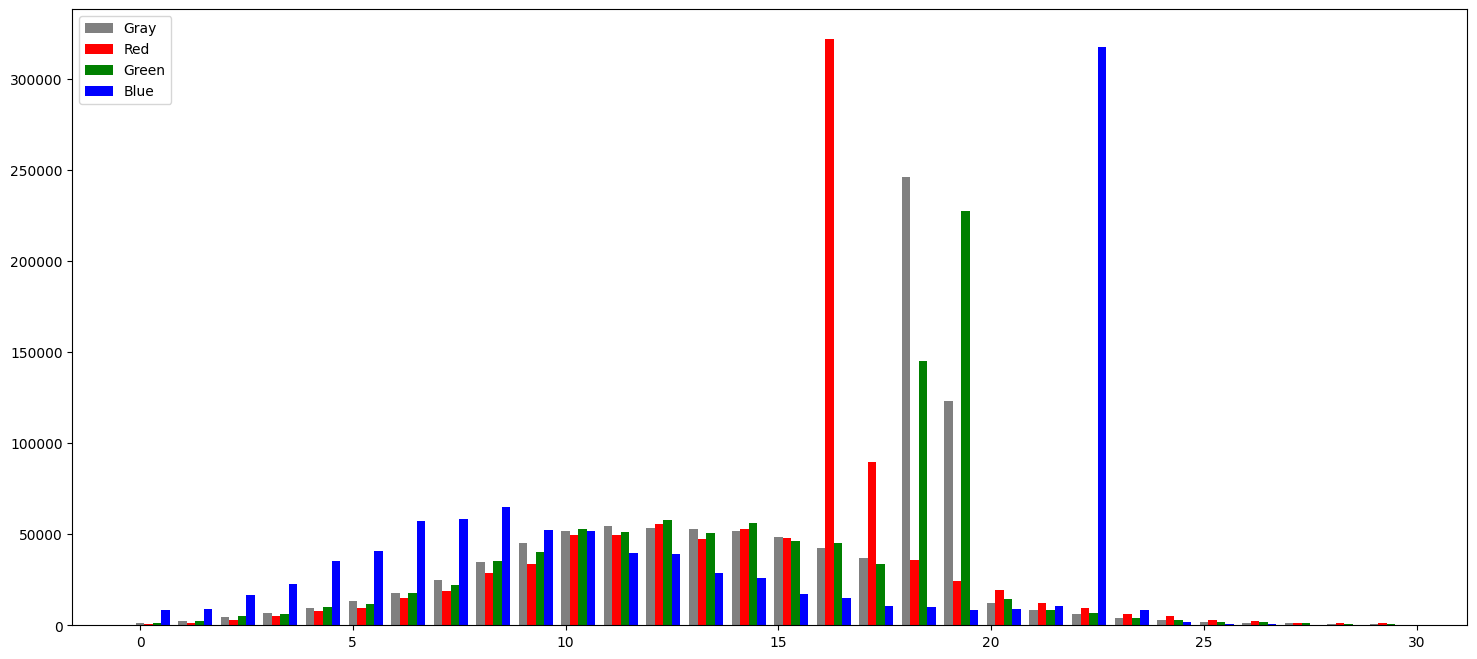

In [5]:
# Alternatively
# We personally like more the solution offered before, but it is how it's done in the tutorial
# and what we think is asked of us here

def alt_im_hist(image, nBins=8):
    hst_r, bins_r = histogram(img_as_float(image[:,:,0]), nbins=nBins)
    hst_g, bins_g = histogram(img_as_float(image[:,:,1]), nbins=nBins)
    hst_b, bins_b = histogram(img_as_float(image[:,:,2]), nbins=nBins)
    hst_cg, bins_cg = histogram(img_as_float(rgb2gray(image)), nbins=nBins)
    
    ind = np.arange(nBins)
    
    fig = plt.figure(figsize=(18,8))
    cl_cg = plt.bar(ind, hst_cg, 0.2, color='gray')
    cl_r = plt.bar(ind+.2, hst_r, 0.2, color='r')
    cl_g = plt.bar(ind+.4, hst_g, 0.2, color='g')
    cl_b = plt.bar(ind+.6, hst_b, 0.2, color='b')
    plt.legend((cl_cg[0], cl_r[0], cl_g[0], cl_b[0]), ('Gray', 'Red', 'Green', 'Blue'), loc=2, prop={'size': 10})
    plt.show()

nBins = 30
alt_im_hist(oryx, nBins)

### 2.2 Grayscale and RGB images filtering (convolutions)

a) Read the image `./images_notebook/oryx.png`. Reshape the image to $256x256$ pixels and convert to gray scale (i.e. `oryx_gray`). We are going to apply:

1. Convolve `oryx_gray` with a horizontal mask `mask_h1d=[[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]]` using the function `ndimage.convolve()` of the package `scipy`.
2. Convolve `oryx_gray` with a transposed version of the mask in (2).
3. Convolve `oryx_gray` with a uniform `two-dimensional` mask of dimensions 15x15 with all values set to 1.

Check the maximum and minimum values, as well as the data type of each imagea.

- Is the type of the mask important for the convolution? What effect does each of the masks produce on the original image? Compare the results.


**Note:** The command `convolve` performs a multidimensional convolution! A vector should be represented as: [[1,...1]].

**Note:** Remember that before applying the `convolve` function the mask must be normalized (i.e. all values in the mask must sum 1).


b) Visualize the four images, `oryx_gray` and the output of each step (1 to 3) in a single figure, with the corresponding titles.


Note: Remember that `matplotlib.pyplot` automatically rescales the values of the image before displaying them. Visualize with and without pixel values range rescaling.


0 float64 0.023931331427080104 0.9855090831044124
1 float64 0.07937665506762269 0.7390661325161817
2 float64 0.09759434890520409 0.8311967360116739
3 float64 0.13676066820026753 0.6406862071602043


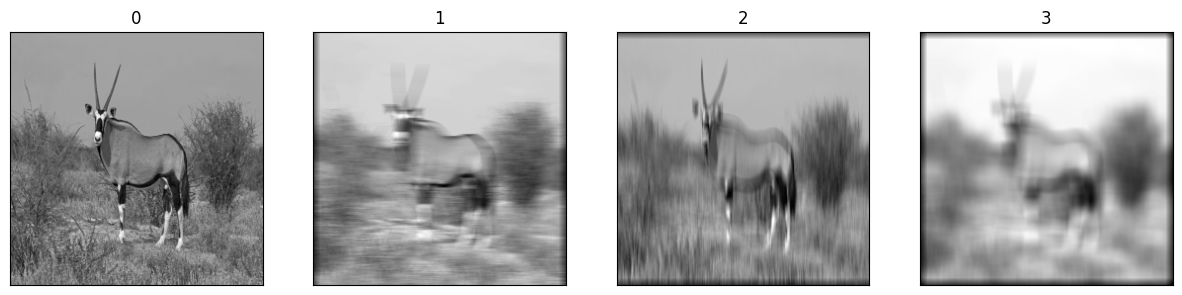

In [6]:
# We merged a and b parts
oryx = img_as_ubyte(io.imread("images_notebook/oryx.jpg"))
oryx_gray = rgb2gray(resize(oryx, (256,256), anti_aliasing=True))

# Masks
mask = np.array([[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]])
mask = mask/np.sum(mask) # Normalize it
transposed_mask = np.transpose(mask)
matrix_mask = np.ones((15,15))
matrix_mask = matrix_mask/np.sum(matrix_mask) # Normalize it

oryx_convolved = convolve(oryx_gray, mask, mode='constant', cval=0.0)
oryx_t_convolved = convolve(oryx_gray, transposed_mask, mode='constant', cval=0.0)
oryx_m_convolved = convolve(oryx_gray, matrix_mask, mode='constant', cval=0.0)

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(15,5))

for i, img in enumerate((oryx_gray, oryx_convolved, oryx_t_convolved, oryx_m_convolved)):
    print(i, img.dtype, img.min(), img.max())
    axs[i].imshow(img, cmap="gray")
    axs[i].set_title(i)
    
plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

c) Can we convolve a color (RGB) image? 

Implement a function `conv_coor(image, mask)` that applies a 3-channel filter.  Reshape the original `oryx.png` image to $256x256$ pixels and try your funcion, using a 7x7 uniform mask.


0 float64 0.009492300577272968 0.9920457655243664 (256, 256, 3)
1 float64 0.07821253193301556 0.8359860773022264 (256, 256, 3)


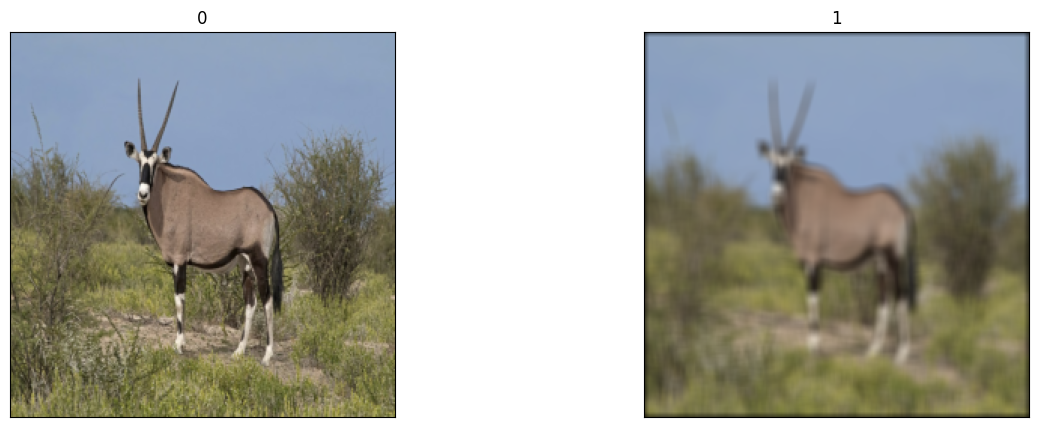

In [7]:
def conv_coor(image, mask):
    img = np.copy(image)
    for i, name in enumerate((r,g,b)):
        name = convolve(img[:,:,i], mask, mode='constant', cval=0.0)
        img[:,:,i] = name
    return img
    
oryx = img_as_ubyte(io.imread("images_notebook/oryx.jpg"))
oryx = resize(oryx, (256,256), anti_aliasing=True)

mask = np.ones((7,7))
mask = mask/np.sum(mask) # Normalize it

rgb_convolved = conv_coor(oryx, mask)
fig, axs = plt.subplots(ncols=2, figsize=(15,5))

for i, img in enumerate((oryx, rgb_convolved)):
    print(i, img.dtype, img.min(), img.max(), img.shape)
    axs[i].imshow(img)
    axs[i].set_title(i)

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

### 2.3 Effect of image scale on convolutions

a) Resize an image and observe the variations in the histograms.

1. Reduce `oryx_gray` 20 times, and check the histogram (i.e. nbins = 32)
2. Augment `oryx_gray` 20 times, and check its histogram (i.e. nbins = 32)

Is there any difference? Please, comment what happens and why.


0 float64 0.27958270311973027 0.6387017645321871
1 float64 0.026341058728294963 0.9851644033852379


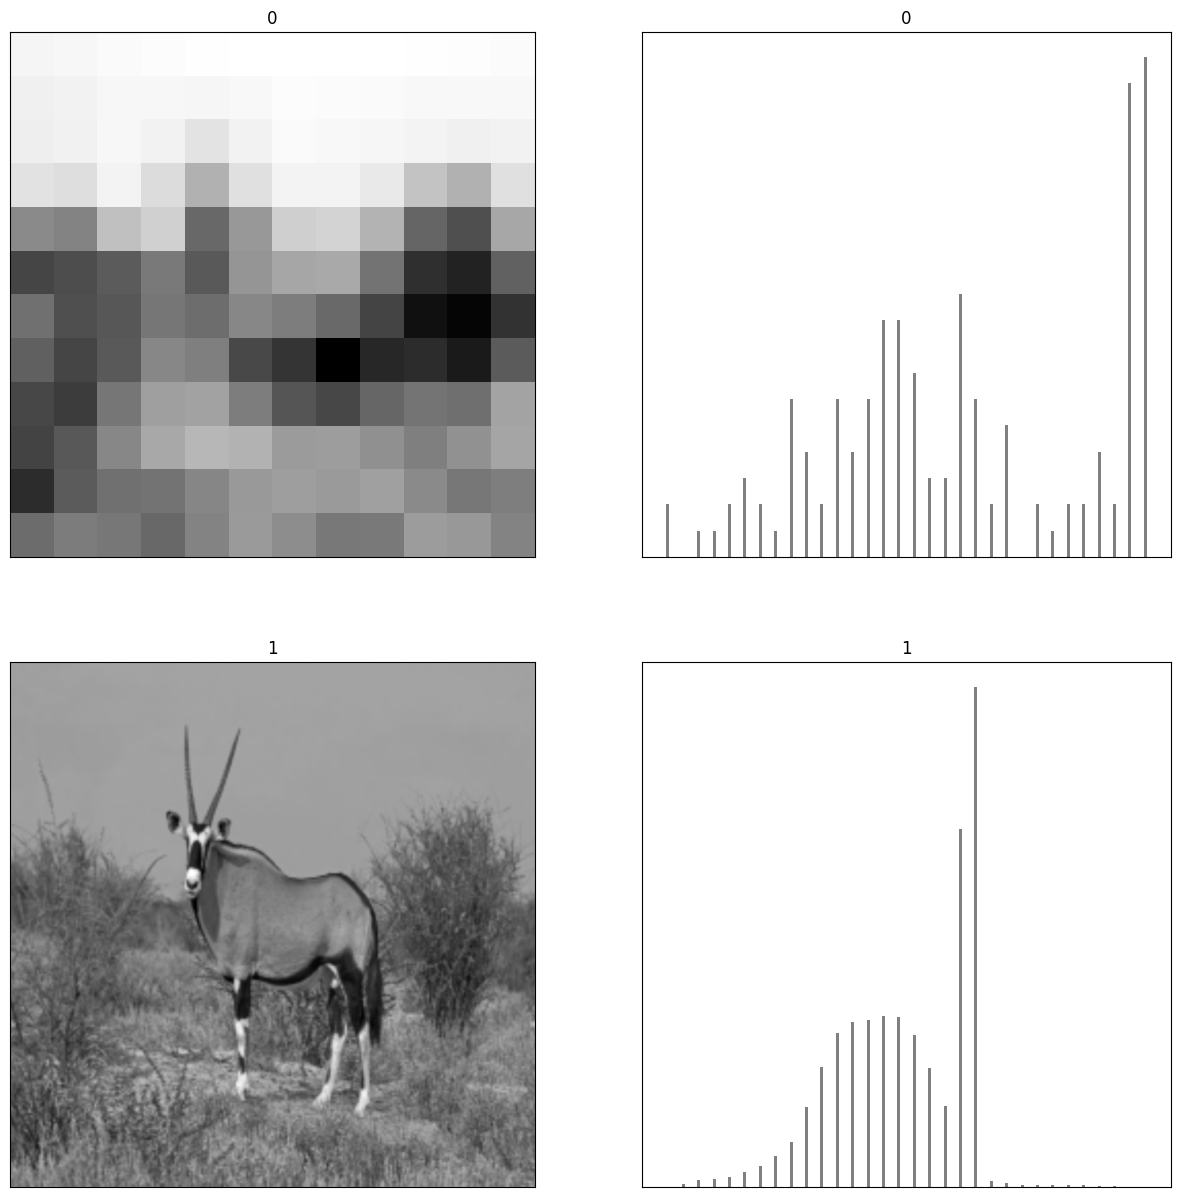

In [8]:
# Supposing we are referring to the spatial resolution ("resize an image")
nBins = 32
h,w = oryx_gray.shape
scaling_factor = 20

# Do the resizing
oryx_r20 = resize(oryx_gray, (w//scaling_factor, h//scaling_factor), anti_aliasing=True)
oryx_a20 = resize(oryx_gray, (w*scaling_factor, h*scaling_factor), anti_aliasing=True)

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15,15))
ind = np.arange(nBins)

for i, img in enumerate((oryx_r20, oryx_a20)):
    print(i, img.dtype, img.min(), img.max())
    hst, bins = histogram(img_as_float(img), nbins=nBins)
    axs[i,0].imshow(img, cmap="gray")
    axs[i,1].bar(ind, hst, 0.2, color='gray')
    axs[i,0].set_title(i); axs[i,1].set_title(i)

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

b) Apply a convolution (7x7 uniform mask) on the resized images, calculate the histograms and compare the results.

1. Convolve the original `oryx_gray`image and calculate its histogram.
2. Convolve the reduced `oryx_gray` image 20 times and calculate its histogram.
3. Convolve the augmented `oryx_gray` image 20 times and calculate its histogram.

Comment what happens and why.

0 float64 0.1082238634235488 0.7914034094065505
1 float64 0.13974598452473877 0.5582026763006328
2 float64 0.028814120633231268 0.9838594886449561


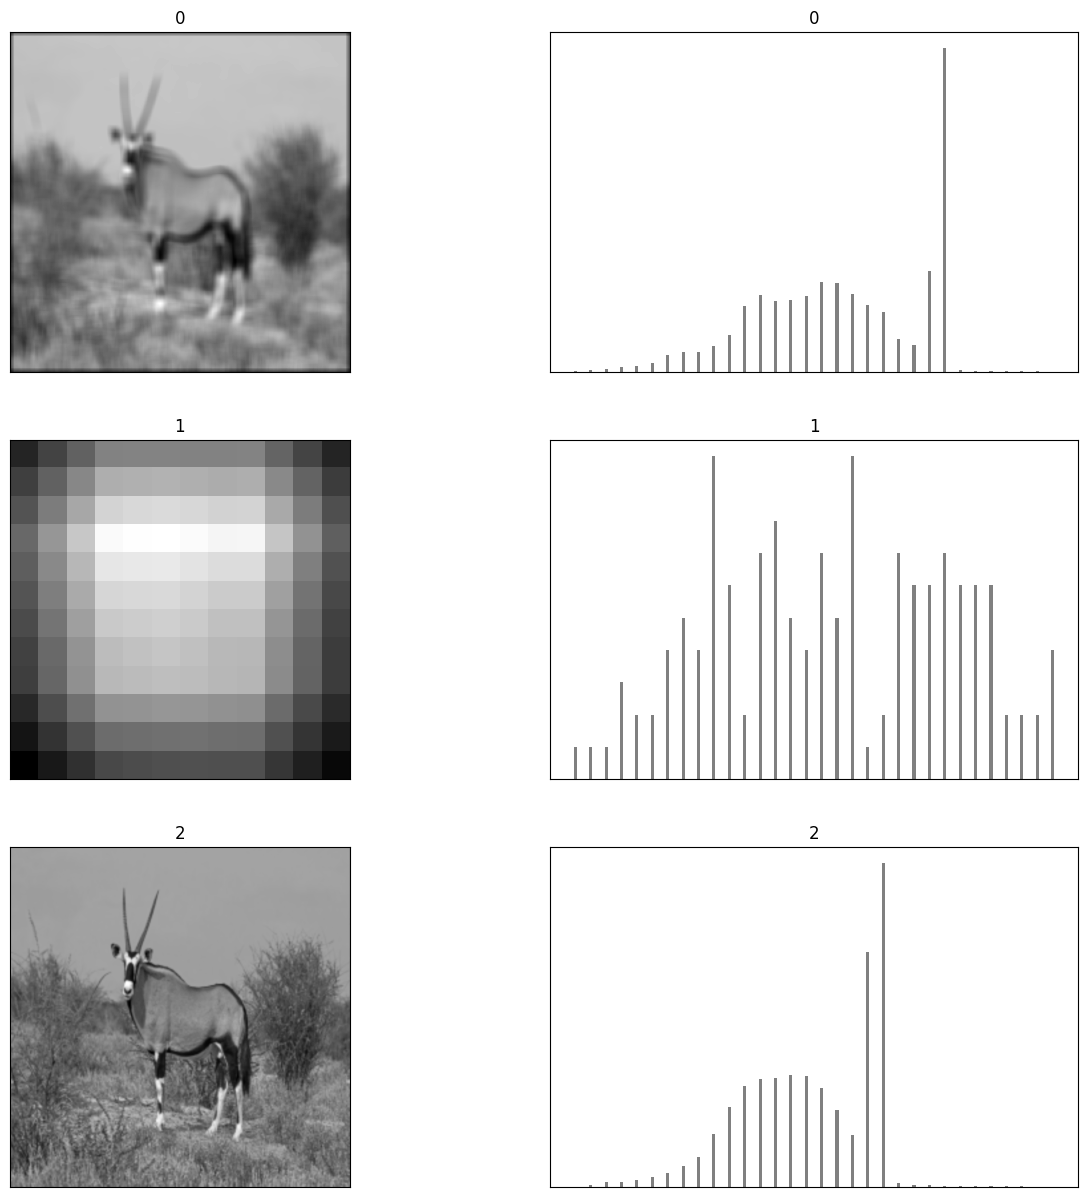

In [9]:
# Supposing we are referring to the spatial resolution ("resize an image")
nBins = 32
h,w = oryx_gray.shape
scaling_factor = 20

# Do the convolving
mask = np.ones((7,7))
mask = mask/np.sum(mask) # Normalize it
oryx_cgray = convolve(oryx_gray, mask, mode='constant', cval=0.0)
oryx_cr20 = convolve(oryx_r20, mask, mode='constant', cval=0.0)
oryx_ca20 = convolve(oryx_a20, mask, mode='constant', cval=0.0)

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(15,15))
ind = np.arange(nBins)

for i, img in enumerate((oryx_cgray, oryx_cr20, oryx_ca20)):
    print(i, img.dtype, img.min(), img.max())
    hst, bins = histogram(img_as_float(img), nbins=nBins)
    axs[i,0].imshow(img, cmap="gray")
    axs[i,1].bar(ind, hst, 0.2, color='gray')
    axs[i,0].set_title(i); axs[i,1].set_title(i)

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

### 2.4 Image processing with weighting and non-linear filters

a) Generate the following kernels and apply them to the `oryx_gray` image:

1. Gaussian kernel with sigma = 1
2. Gaussian kernel with 3 different sigma values. Which is the most adequate value for keeping the main objects and structures of the image?
3. Median filter with different mask shapes: disk, rectangle, and diamond. What is the effect of using different kinds of filters on the original image?

Comment the effect of using different kinds of filters on the original image.

**Hint:** Search for the [skimage.filters function](https://scikit-image.org/docs/stable/api/skimage.filters.html) for creating the different filters.

In [10]:
from skimage.filters import gaussian
from skimage.filters import median
from skimage.morphology import disk, rectangle, diamond

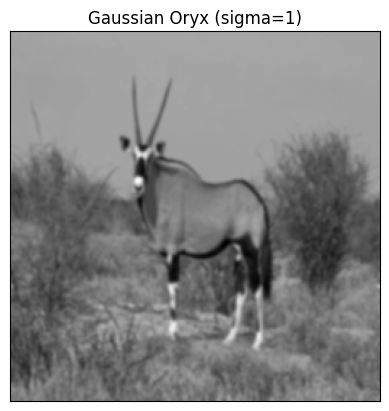

In [11]:
gaussian1_oryx = gaussian(oryx_gray, sigma=1)
plt.imshow(gaussian1_oryx, cmap="gray")
plt.xticks([]); plt.yticks([]) # Off ticks
plt.title("Gaussian Oryx (sigma=1)")
plt.show()

0 float64 0.04445206329506553 0.980072233587078
1 float64 0.06975888704047087 0.946711863124178
2 float64 0.13600752671424007 0.7549683656546029
3 float64 0.19168473120515805 0.6403899550299048


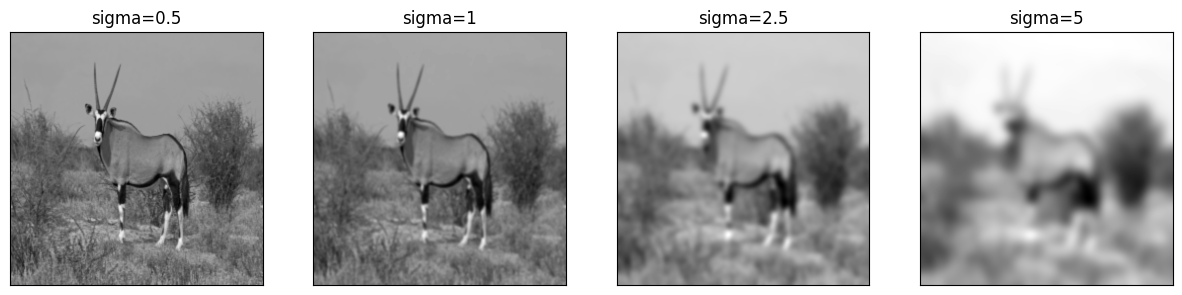

In [12]:
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(15,5))

for i, num in enumerate((0.5,1,2.5,5)):
    img = gaussian(oryx_gray, sigma=num)
    print(i, img.dtype, img.min(), img.max())
    axs[i].imshow(img, cmap="gray")
    axs[i].set_title(f"sigma={num}")

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

The most adequate sigma value for keeping the main objects and structures of the image  while still reducing noise is typically in the small to medium range (between σ=1.0 and σ=2.0). Small σ (e.g., σ=0.5 or σ=1.0): This will result in minimal blurring. Fine details and noise are slightly reduced, but the main objects and edges remain sharp. Best for cases where you want to reduce noise without losing important structures.

0 float64 0.023931331427080104 0.9855090831044124
1 float64 0.03441432412251533 0.9789523947787087
2 float64 0.03941501109421606 0.9693831608527124
3 float64 0.071619752419344 0.912552131296132
4 float64 0.09772094350285294 0.8383402960670524


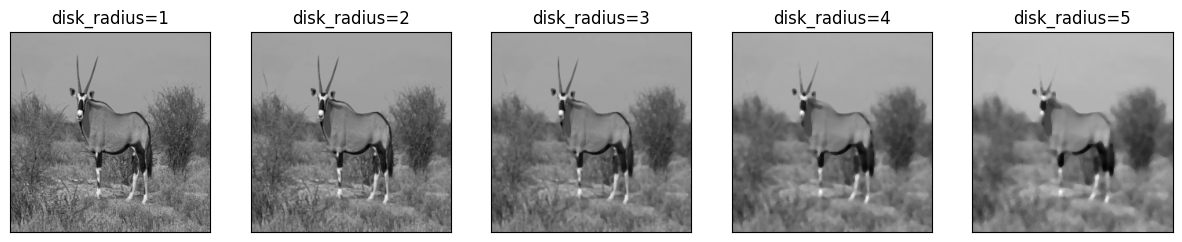

In [13]:
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(15,5))

# We modify disk radius
for i, num in enumerate(range(1, 6)):
    img = median(oryx_gray, disk(i))
    print(i, img.dtype, img.min(), img.max())
    axs[i].imshow(img, cmap="gray")
    axs[i].set_title(f"disk_radius={num}")

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

1 float64 0.03941501109421606 0.8971409980470043
2 float64 0.0695638508083033 0.890136863586058
3 float64 0.06125539803234583 0.9192226763693427
4 float64 0.10642776224744785 0.8444968257914499
5 float64 0.10642776224744785 0.8145680926504785


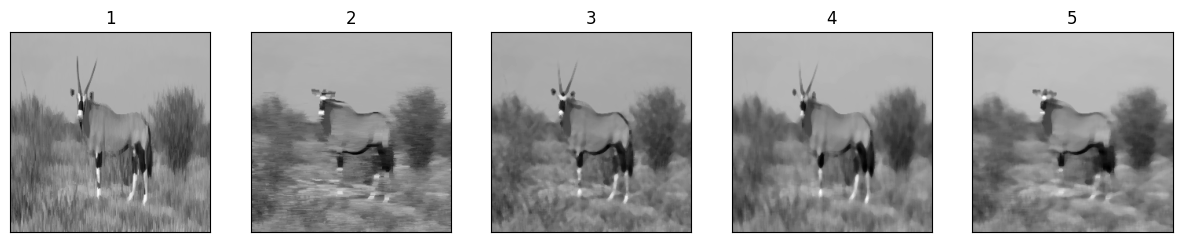

In [14]:
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(15,5))

# Create some rectangle masks which are useful
rect1_oryx = median(oryx_gray, rectangle(10,1))
rect2_oryx = median(oryx_gray, rectangle(1,10))
rect3_oryx = median(oryx_gray, rectangle(5,5))
rect4_oryx = median(oryx_gray, rectangle(10,5))
rect5_oryx = median(oryx_gray, rectangle(5,10))

# We do the same with rectangle
for i, img in enumerate((rect1_oryx,rect2_oryx,rect3_oryx,rect4_oryx,rect5_oryx)):
    print(i+1, img.dtype, img.min(), img.max())
    axs[i].imshow(img, cmap="gray")
    axs[i].set_title(i+1)

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

0 float64 0.023931331427080104 0.9855090831044124
1 float64 0.03441432412251533 0.9789523947787087
2 float64 0.03941501109421606 0.9693831608527124
3 float64 0.06125539803234583 0.9192226763693427
4 float64 0.08274910342087229 0.8520082636022257


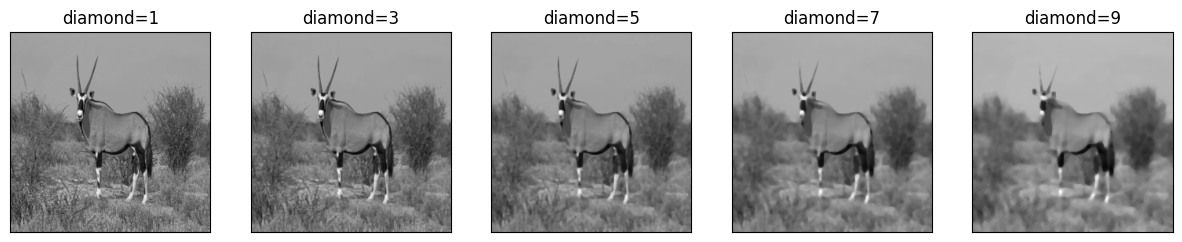

In [15]:
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(15,5))

# Ídem. diamond
for i, num in enumerate(range(1, 10, 2)):
    img = median(oryx_gray, diamond(i))
    print(i, img.dtype, img.min(), img.max())
    axs[i].imshow(img, cmap="gray")
    axs[i].set_title(f"diamond={num}")

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

b) **(Optional)** Apply the smoothing on some other images and present their results.

In [16]:
from skimage import data

0 float64 0.0 1.0
1 float64 0.0 1.0
2 float64 0.0 1.0
3 float64 0.0 0.996078431372549
4 float64 0.0 0.996078431372549
0 float64 0.0002827450980392157 1.0
1 float64 0.013110980392156864 0.9966666666666666
2 float64 0.014249803921568627 0.9950000000000001
3 float64 0.016221960784313726 0.9950000000000001
4 float64 0.016749803921568628 0.9950000000000001
0 float64 0.01512078431372549 0.7556109803921569
1 float64 0.01904235294117647 0.7536388235294118
2 float64 0.0196078431372549 0.7516894117647059
3 float64 0.022963921568627452 0.7497172549019608
4 float64 0.02493607843137255 0.7497172549019608


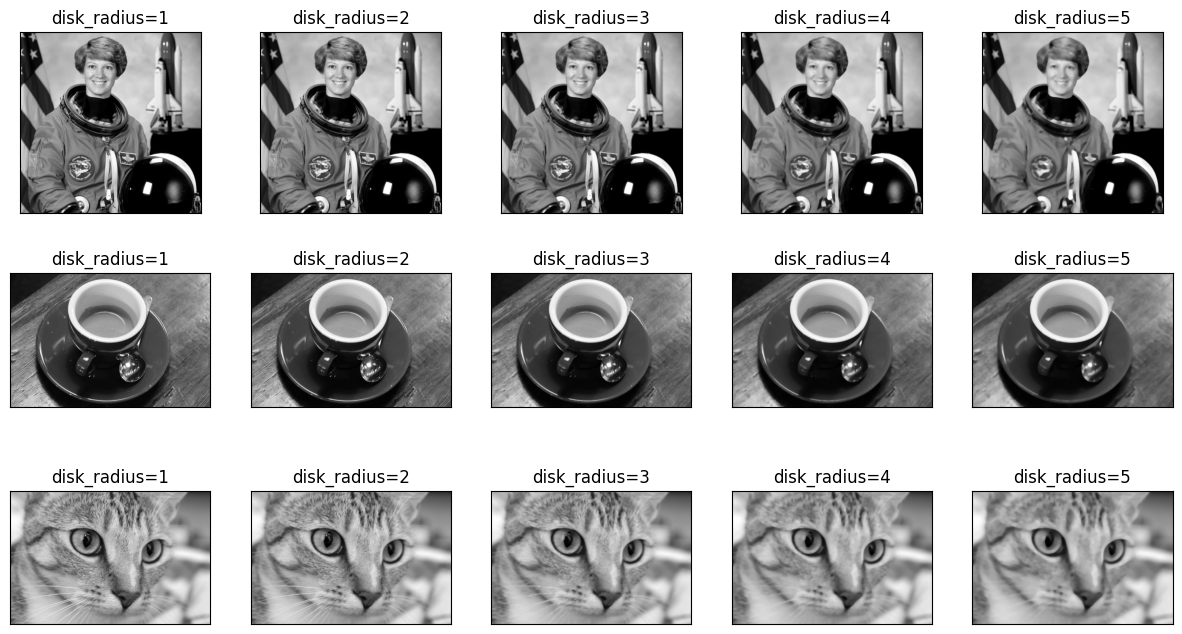

In [17]:
fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(15,8))
astronaut = rgb2gray(img_as_ubyte(data.astronaut()));
coffee = rgb2gray(data.coffee());
cat = rgb2gray(img_as_ubyte(data.cat()));

# DISK
for i, img in enumerate((astronaut, coffee, cat)):
    for j, num in enumerate(range(1, 6)):
        new_img = median(img, disk(j))
        print(j, new_img.dtype, new_img.min(), new_img.max())
        axs[i,j].imshow(new_img, cmap="gray")
        axs[i,j].set_title(f"disk_radius={num}")

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

0 float64 0.0 1.0
1 float64 0.0 1.0
2 float64 0.0 1.0
3 float64 0.0 0.996078431372549
4 float64 0.0 0.996078431372549
0 float64 0.0002827450980392157 1.0
1 float64 0.013110980392156864 0.9966666666666666
2 float64 0.014249803921568627 0.9950000000000001
3 float64 0.015916470588235296 0.9950000000000001
4 float64 0.016749803921568628 0.9950000000000001
0 float64 0.01512078431372549 0.7556109803921569
1 float64 0.01904235294117647 0.7536388235294118
2 float64 0.0196078431372549 0.7516894117647059
3 float64 0.021580000000000002 0.7497172549019608
4 float64 0.023529411764705882 0.7497172549019608


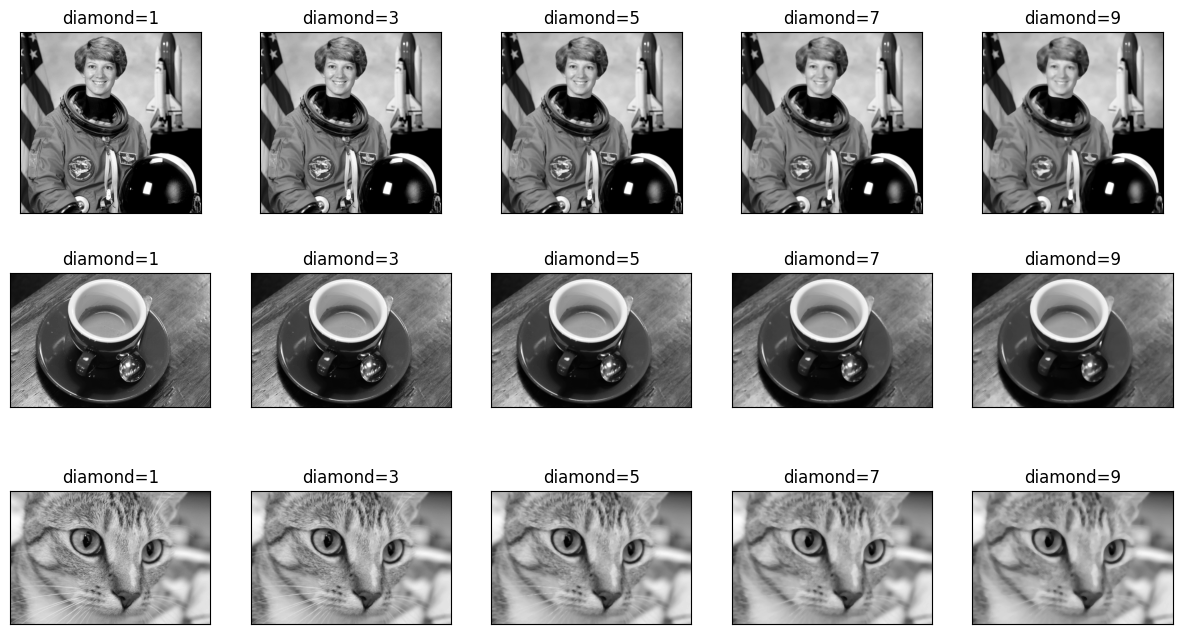

In [18]:
fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(15,8))
astronaut = rgb2gray(img_as_ubyte(data.astronaut()));
coffee = rgb2gray(data.coffee());
cat = rgb2gray(img_as_ubyte(data.cat()));

# DIAMOND
for i, img in enumerate((astronaut, coffee, cat)):
    for j, num in enumerate(range(1, 10, 2)):
        new_img = median(img, diamond(j))
        print(j, new_img.dtype, new_img.min(), new_img.max())
        axs[i,j].imshow(new_img, cmap="gray")
        axs[i,j].set_title(f"diamond={num}")

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

### 2.5 Determine the optimal contour 

a) Load the 'logo_pozo.jpg' image and visualize its contours.	

<img src="images_notebook/logo_pozo.jpg" width="400" height="400">


Apply the different contour extraction tecniques introduced during the theory session and change any parameter if necessary for detecting the edges of the image:

1. Prewitt
2. Sobel
3. Canny

Use subplot and title to visualize the results.

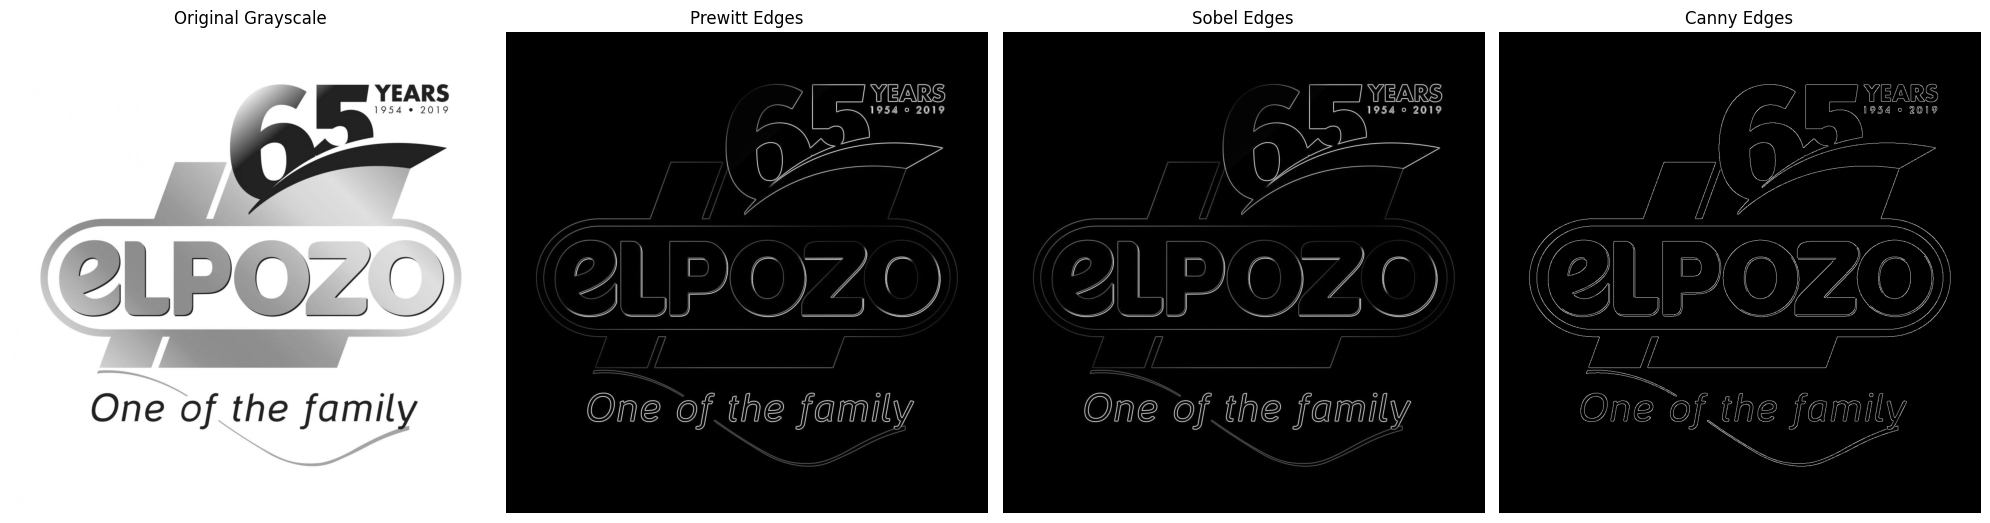

In [19]:
import warnings
from skimage import filters, feature

warnings.filterwarnings("ignore")
elpozo = rgb2gray(io.imread("images_notebook/logo_pozo.jpg"))

# Apply different edge detection techniques
prewitt_edges = filters.prewitt(elpozo)
sobel_edges = filters.sobel(elpozo)
canny_edges = feature.canny(elpozo, sigma=1)

# Plot the results
fig, axes = plt.subplots(1, 4, figsize=(20, 10))
ax = axes.ravel()

# Original image
ax[0].imshow(elpozo, cmap='gray')
ax[0].set_title("Original Grayscale")
ax[0].axis('off')

# Prewitt edge detection
ax[1].imshow(prewitt_edges, cmap='gray')
ax[1].set_title("Prewitt Edges")
ax[1].axis('off')

# Sobel edge detection
ax[2].imshow(sobel_edges, cmap='gray')
ax[2].set_title("Sobel Edges")
ax[2].axis('off')

# Canny edge detection
ax[3].imshow(canny_edges, cmap='gray')
ax[3].set_title("Canny Edges")
ax[3].axis('off')

plt.tight_layout()
plt.show()

#### **Questions**

- Which is the best countour detection technique? 

- Which are the optimal parameters for this image? 

- Is it necessary to normalize the mask as we do in the filtering applied for the smoothing? 

**Hint**: use `skimage.feature.canny` for applying the canny filter and `skimage.filters` for the rest.

#### Answers
AAAA

**(Optional)** Superimpose the contours over the image.

In [20]:
# K?

b)	Repeat the experiment with other images, you can use the ones included in the folder **images**. Comment if some parameter needs to be changed for the different images.

#### **Questions**

- Are the contours improved if the image is previously smoothed? 
- Which are the limitations of the different images contour extraction?

#### Answers
AAAA

In [21]:
# Let's use oryx (not resized, we will charge it again), car and Messi (best player in the world)
oryx = rgb2gray(io.imread("images_notebook/oryx.jpg"))
car = rgb2gray(io.imread("images_notebook/car.png"))
messi = rgb2gray(io.imread("images_notebook/messi.jpg"))

0 float64 0.0 0.6841568048337678
1 float64 0.0 0.7258849968453243
0 float64 0.0 0.21306100444031192
1 float64 0.0 0.21937132955708155
0 float64 0.0 0.5170152972202898
1 float64 0.0 0.5316972389228855


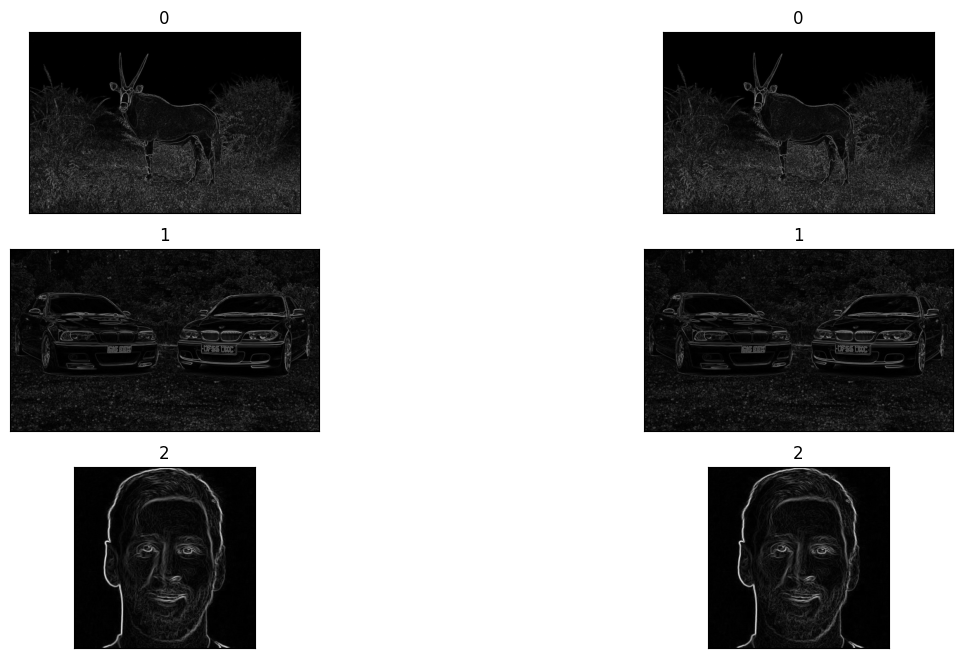

In [22]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(15,8))

# Prewitt and sobel contourings
for i, img in enumerate((oryx, car, messi)):
    prewitt = filters.prewitt(img)
    sobel = filters.sobel(img)
    for j, filtered in enumerate((prewitt, sobel)):
        print(j, filtered.dtype, filtered.min(), filtered.max())
        axs[i,j].imshow(filtered, cmap="gray")
        axs[i,j].set_title(i)

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

0 bool False True
1 bool False True
2 bool False True
3 bool False True
4 bool False True
0 bool False True
1 bool False True
2 bool False True
3 bool False True
4 bool False True
0 bool False True
1 bool False True
2 bool False True
3 bool False True
4 bool False True


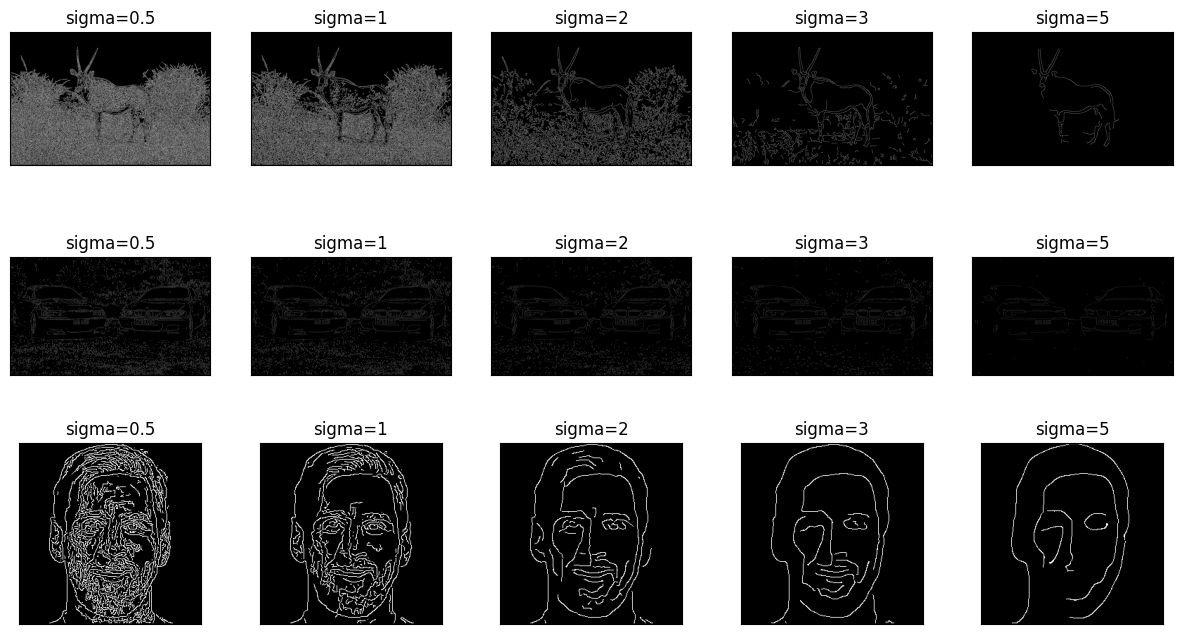

In [23]:
fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(15,8))

# We will do the same with Canny, but changing sigma values
for i, img in enumerate((oryx, car, messi)):
    for j, sigma in enumerate((0.5,1,2,3,5)):
        canny = feature.canny(img, sigma=sigma)
        print(j, canny.dtype, canny.min(), canny.max())
        axs[i,j].imshow(canny, cmap="gray")
        axs[i,j].set_title(f"sigma={sigma}")
        
plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

c) Apply the Sobel and Prewwit filters using the `convolve` function instead of the `skimage.filters` package. Compare the results.


0 float64 0.0 2.9026314965572717
1 float64 0.0 4.106225629047236
0 float64 0.0 0.9039412862769701
1 float64 0.0 1.2409516378217702
0 float64 0.0 2.193510135849872
1 float64 0.0 3.00773378544429


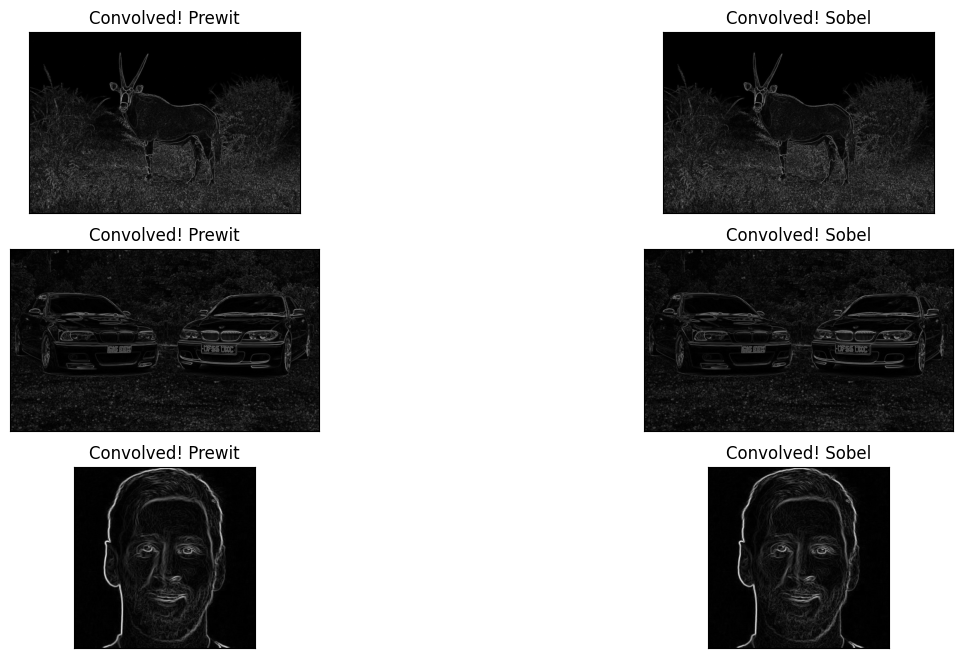

In [24]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(15,8))

# We can define the Sobel and Prewitt kernels for x and y directions
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

prewitt_x = np.array([[-1, 0, 1],
                      [-1, 0, 1],
                      [-1, 0, 1]])

prewitt_y = np.array([[-1, -1, -1],
                      [ 0,  0,  0],
                      [ 1,  1,  1]])

# The gradient magnitude is given by G=sqrt{G_x^2+G_y^2}, so we
# will use np.hypot() to do so

# Prewitt and sobel contourings
for i, img in enumerate((oryx, car, messi)):
    
    # Sobel edge detection using convolution
    sobel_x_conv = convolve(img, sobel_x)
    sobel_y_conv = convolve(img, sobel_y)
    sobel = np.hypot(sobel_x_conv, sobel_y_conv)
    
    # Prewitt edge detection using convolution
    prewitt_x_conv = convolve(img, prewitt_x)
    prewitt_y_conv = convolve(img, prewitt_y)
    prewitt = np.hypot(prewitt_x_conv, prewitt_y_conv)
    
    for j, filtered in enumerate((prewitt, sobel)):
        print(j, filtered.dtype, filtered.min(), filtered.max())
        axs[i,j].imshow(filtered, cmap="gray")
        # Una mica cutre, s'hauria de canviar
        axs[i,j].set_title(f"Convolved! {"Prewit" if j==0 else "Sobel"}")

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

### 2.6 Applying smoothing in order to obtain hybrid images

a) Given `./images_notebook/messi.jpg` and `./images_notebook/cr.jpg` images:

1. Plot both images.
2. Apply a low-pass filter to both of them and plot them.
3. Apply a high-pass filter to both of them and plot them.

The result should be something like:

![messi](images_notebook/Messi.png) 

![cr](images_notebook/CR.png)


By applying smoothing over an image I, we apply a `low-pass` filter. The resulting image can be called L(I). If we substract the filtered one from the original image, we obtain its high frequencies, that we can call H(I), i.e. we apply a `high-pass` filter. 

***H(I) = I - L(I)***

Hint: In order to highlight the effect, in the L(I) image you should define a lower sigma, while for the H(I) you should use a higher one. 

0 float64 0.0 1.0
1 float64 0.0007804837589121436 0.9477984570805471
2 float64 0.0 0.4839905511138378
0 float64 0.0 1.0
1 float64 0.06883408947746031 0.9898601742122155
2 float64 0.0 0.47581969815750286


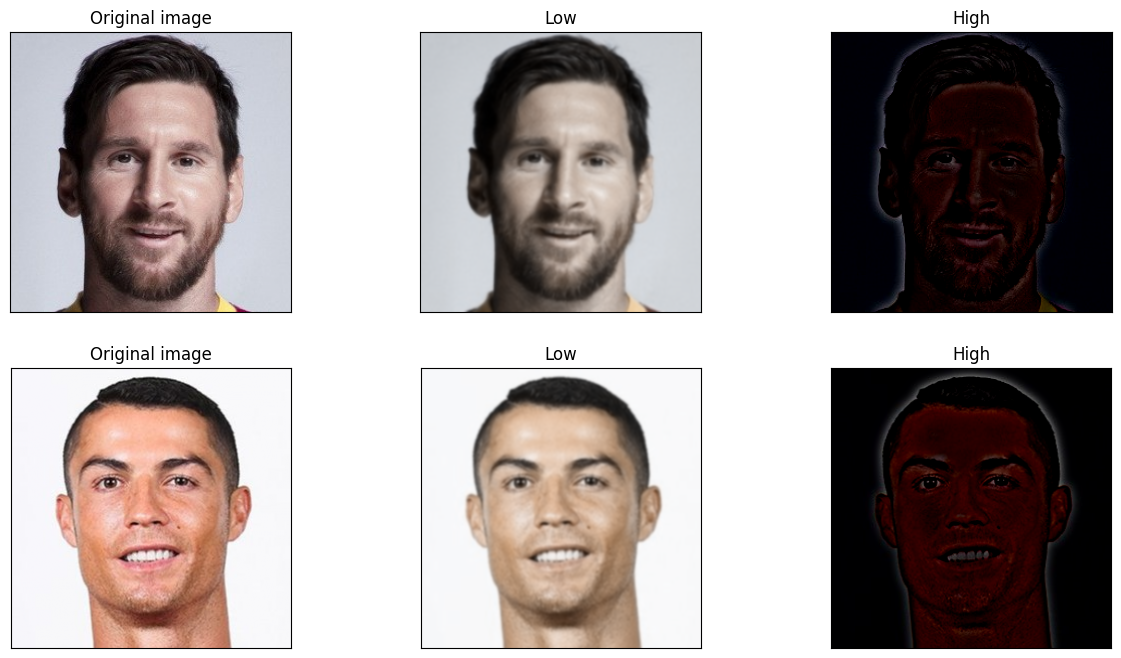

In [25]:
messi = io.imread("images_notebook/messi.jpg")
ronaldo = io.imread("images_notebook/cr.jpg")

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15,8))

# Prewitt and sobel contourings
titles = ["Original image", "Low", "High"]
for i, img in enumerate((messi, ronaldo)):
    original = img_as_float(img)
    low_pass = filters.gaussian(original, sigma=1)
    high_pass = filters.gaussian(original, sigma=5)
    high_pass = np.clip(original - high_pass, 0, 1)
    
    for j, filtered in enumerate((original, low_pass, high_pass)):
        print(j, filtered.dtype, filtered.min(), filtered.max())
        axs[i,j].imshow(filtered, cmap='gray')
        axs[i,j].set_title(titles[j])

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

b) Create hybrid images and visualize them. A hybrid image is obtained by combining the low and high frequencies of the image, i.e. combining the results obtained by the `low-pass` and `high-pass` filters.

<img src="images_notebook/Fusion.gif" width="400" height="400">

Hybrid (I1, I2) = L(I1) + H(I2)

1. Analyze which is the best way of showing it if our aim is to see Messi's face. 
2. Additionally, rescale the image to a different size and comment the results. 

Present the different visualizations of the experiment performed.

<img src="images_notebook/Hybrid.png">


2 float64 (258, 259, 3) 0.0 1.0
2 float64 (258, 259, 3) 0.0 1.0


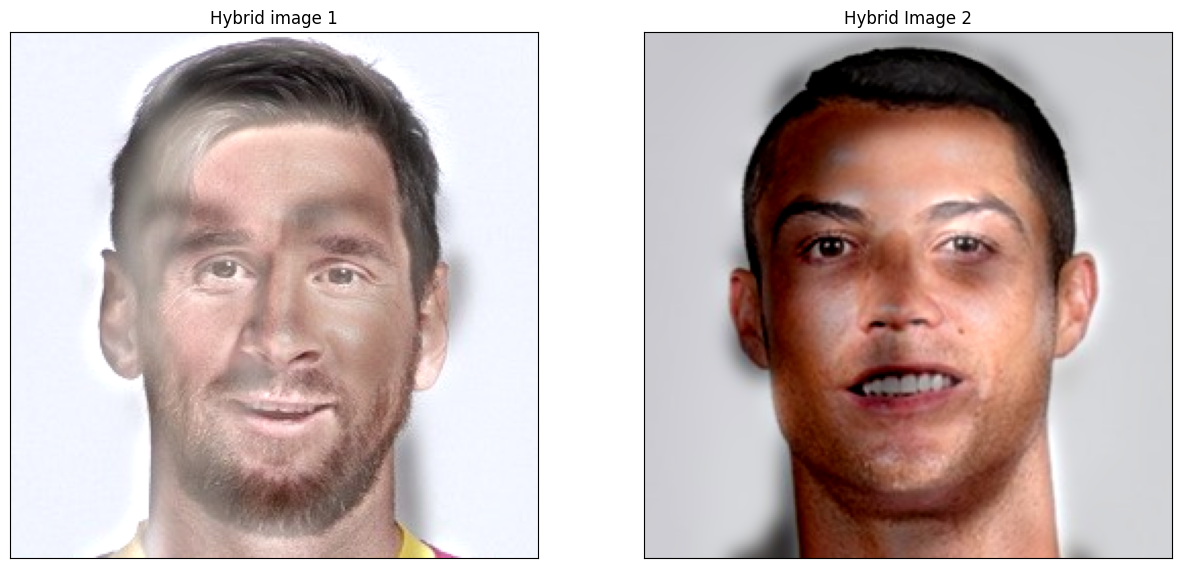

In [41]:
messi = img_as_float(io.imread("images_notebook/messi.jpg"))
ronaldo = img_as_float(io.imread("images_notebook/cr.jpg"))

# Ronaldo kneels before Messi
ronaldo = resize(ronaldo, messi.shape[:2], anti_aliasing=True)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,8))

# Prewitt and sobel contourings
titles = ["Hybrid image 1", "Hybrid Image 2"]

low_pass = filters.gaussian(ronaldo, sigma=5)
high_pass = messi - filters.gaussian(messi, sigma=5)
messialdo = np.clip(low_pass + high_pass, 0, 1)

low_pass = filters.gaussian(messi, sigma=5)
high_pass = ronaldo - filters.gaussian(ronaldo, sigma=5)
romessi = np.clip(low_pass + high_pass, 0, 1)
    
for i, img in enumerate((messialdo, romessi)):
    print(j, img.dtype, img.shape, img.min(), img.max())
    axs[i].imshow(img)
    axs[i].set_title(titles[i])

plt.setp(axs, xticks=[], yticks=[]) # Off ticks
plt.show()

### 2.7 Anonimization of sensitive information

One of the important problems in Computer Vision as a science that manages data (images and videos) is the anonimization of sensitive information appearing in the images.
For example, it is common in applications like Google Street View, where the faces and license plates are anonymized.
The file `./images_notebook/car.png` contains two cars. Anonimize the license plates of the cars using the techniques learned in this practicum.

Modify only the license plates of the cars, keeping the rest of the image unchanged.

![car](images_notebook/car.png)

In [49]:
def plate_hiding(license_plates):
    
    anon = np.copy(car)
    for (x,y,w,h) in license_plates:
        region = anon[y:y+h, x:x+w]
        blur = img_as_ubyte(filters.gaussian(region, sigma=30))
        anon[y:y+h, x:x+w] = blur
    
    titles = ["Original image", "Anonymized image"]
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,8))
    for i, img in enumerate((car, anon)):
        print(titles[i], img.dtype, img.shape, img.min(), img.max())
        axs[i].imshow(img, cmap='gray')
        axs[i].set_title(titles[i])
    
    plt.setp(axs, xticks=[], yticks=[]) # Off ticks
    plt.show()

Original image uint8 (2252, 3840, 3) 0 255
Anonymized image uint8 (2252, 3840, 3) 0 255


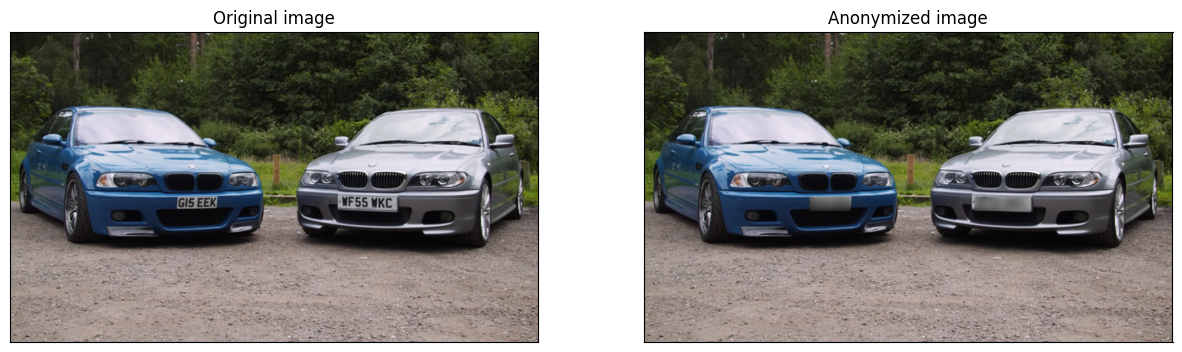

In [50]:
# NAIVE SOLUTION
car = io.imread("./images_notebook/car.png")
license_plates = [(1200, 1200, 300, 100), (2400, 1200, 400, 100)]
plate_hiding(license_plates)